# Nepal Weather Prediction - ML Pipeline

This demonstrates the end-to-end Machine Learning pipeline for the Nepal Weather Prediction project. It covers Data Inspection, Data Cleaning, Exploratory Data Analysis (EDA), Feature Engineering, Model Training, and Evaluation.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set seaborn style for plots
sns.set_theme(style="darkgrid")

## 1. Data Inspection & Cleaning

In [2]:
# Load Dataset
df = pd.read_csv('../data/nepal_293_cities_weather_2020_2025.csv')

# Parse Dates
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
df = df.dropna(subset=['Date'])

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (447719, 21)


,Date,City,District,Latitude,Longitude,Precip,Pressure,Humidity_2m,RH_2m,Temp_2m,...,MaxTemp_2m,MinTemp_2m,EarthSkinTemp,WindSpeed_10m,MaxWindSpeed_10m,MinWindSpeed_10m,WindSpeed_50m,MaxWindSpeed_50m,MinWindSpeed_50m,Temp_2m_tomorrow
0,2020-07-19,Sanphebagar,Achham,29.12,81.3,0,86.93,19.69,93.48,23.59,...,25.70,21.35,23.69,2.31,3.47,0.93,3.10,4.89,1.50,24.24
1,2020-07-20,Sanphebagar,Achham,29.12,81.3,0,86.79,19.68,90.34,24.24,...,27.68,21.82,24.73,2.78,4.80,1.54,3.75,5.32,2.43,23.33
2,2020-07-21,Sanphebagar,Achham,29.12,81.3,0,87.09,18.52,90.08,23.33,...,26.79,21.08,23.64,2.11,4.08,0.20,2.70,4.46,0.20,23.58
3,2020-07-22,Sanphebagar,Achham,29.12,81.3,0,87.10,17.31,83.29,23.58,...,27.51,20.61,23.68,1.52,3.31,0.27,1.72,3.19,0.40,22.63
4,2020-07-23,Sanphebagar,Achham,29.12,81.3,0,87.17,17.35,88.13,22.63,...,26.24,20.17,22.85,1.94,4.34,0.32,2.61,4.84,0.30,22.37


In [3]:
# Map Districts to Provinces
DISTRICT_TO_PROVINCE = {
    "Bhojpur": "Koshi", "Dhankuta": "Koshi", "Ilam": "Koshi", "Jhapa": "Koshi", "Khotang": "Koshi", "Morang": "Koshi", "Okhaldhunga": "Koshi", "Panchthar": "Koshi", "Sankhuwasabha": "Koshi", "Solukhumbu": "Koshi", "Sunsari": "Koshi", "Taplejung": "Koshi", "Terhathum": "Koshi", "Udayapur": "Koshi",
    "Bara": "Madhesh", "Dhanusha": "Madhesh", "Mahottari": "Madhesh", "Parsa": "Madhesh", "Rautahat": "Madhesh", "Saptari": "Madhesh", "Sarlahi": "Madhesh", "Siraha": "Madhesh",
    "Bhaktapur": "Bagmati", "Chitwan": "Bagmati", "Dhading": "Bagmati", "Dolakha": "Bagmati", "Kathmandu": "Bagmati", "Kavrepalanchok": "Bagmati", "Lalitpur": "Bagmati", "Makwanpur": "Bagmati", "Nuwakot": "Bagmati", "Ramechhap": "Bagmati", "Rasuwa": "Bagmati", "Sindhuli": "Bagmati", "Sindhupalchok": "Bagmati",
    "Baglung": "Gandaki", "Gorkha": "Gandaki", "Kaski": "Gandaki", "Lamjung": "Gandaki", "Manang": "Gandaki", "Mustang": "Gandaki", "Myagdi": "Gandaki", "Nawalpur": "Gandaki", "Parbat": "Gandaki", "Syangja": "Gandaki", "Tanahun": "Gandaki",
    "Arghakhanchi": "Lumbini", "Banke": "Lumbini", "Bardiya": "Lumbini", "Dang": "Lumbini", "Gulmi": "Lumbini", "Kapilvastu": "Lumbini", "Parasi": "Lumbini", "Palpa": "Lumbini", "Pyuthan": "Lumbini", "Rolpa": "Lumbini", "Rupandehi": "Lumbini", "East Rukum": "Lumbini",
    "Dailekh": "Karnali", "Dolpa": "Karnali", "Humla": "Karnali", "Jajarkot": "Karnali", "Jumla": "Karnali", "Kalikot": "Karnali", "Mugu": "Karnali", "Salyan": "Karnali", "Surkhet": "Karnali", "West Rukum": "Karnali",
    "Achham": "Sudurpashchim", "Baitadi": "Sudurpashchim", "Bajhang": "Sudurpashchim", "Bajura": "Sudurpashchim", "Dadeldhura": "Sudurpashchim", "Darchula": "Sudurpashchim", "Doti": "Sudurpashchim", "Kailali": "Sudurpashchim", "Kanchanpur": "Sudurpashchim"
}
df['Province'] = df['District'].map(DISTRICT_TO_PROVINCE).fillna('Unknown')
df = df.sort_values(by=['City', 'Date']).reset_index(drop=True)
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Date                0
City                0
District            0
Latitude            0
Longitude           0
Precip              0
Pressure            0
Humidity_2m         0
RH_2m               0
Temp_2m             0
WetBulbTemp_2m      0
MaxTemp_2m          0
MinTemp_2m          0
EarthSkinTemp       0
WindSpeed_10m       0
MaxWindSpeed_10m    0
MinWindSpeed_10m    0
WindSpeed_50m       0
MaxWindSpeed_50m    0
MinWindSpeed_50m    0
Temp_2m_tomorrow    0
Province            0
dtype: int64


## 2. Exploratory Data Analysis (EDA)

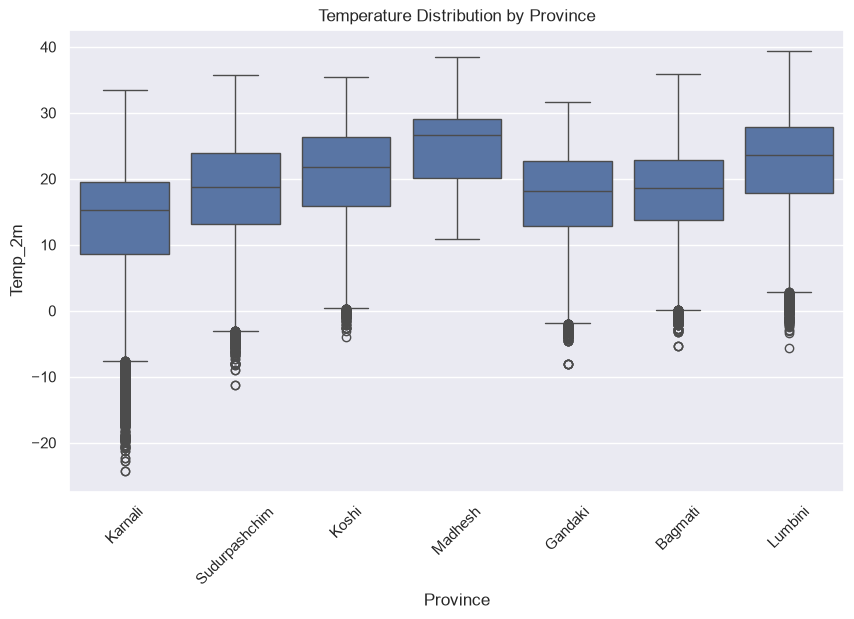

In [4]:
# Temperature distribution across Provinces
plt.figure(figsize=(10, 6))
sns.boxplot(x='Province', y='Temp_2m', data=df)
plt.title('Temperature Distribution by Province')
plt.xticks(rotation=45)
plt.show()

## 3. Feature Engineering

In [5]:
def feature_engineering(df):
    df = df.copy()
    # Temporal
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['DayOfYear'] = df['Date'].dt.dayofyear
    
    df['Month_sin'] = np.sin(2 * np.pi * df['Month']/12)
    df['Month_cos'] = np.cos(2 * np.pi * df['Month']/12)
    df['DayOfYear_sin'] = np.sin(2 * np.pi * df['DayOfYear']/365.25)
    df['DayOfYear_cos'] = np.cos(2 * np.pi * df['DayOfYear']/365.25)
    
    # Lags & Rolling Means
    grouped = df.groupby('City')
    df['Temp_2m_lag1'] = grouped['Temp_2m'].shift(1)
    df['Precip_lag1'] = grouped['Precip'].shift(1)
    df['RH_2m_lag1'] = grouped['RH_2m'].shift(1)
    
    df['Temp_2m_roll3'] = grouped['Temp_2m'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
    df['Temp_2m_roll7'] = grouped['Temp_2m'].rolling(window=7, min_periods=1).mean().reset_index(level=0, drop=True)
    df['Precip_roll3'] = grouped['Precip'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
    df['RH_2m_roll3'] = grouped['RH_2m'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
    
    # Targets
    df['Precip_tomorrow'] = grouped['Precip'].shift(-1)
    df['RH_2m_tomorrow'] = grouped['RH_2m'].shift(-1)
    return df

df_engineered = feature_engineering(df)
df_engineered.head()

,Date,City,District,Latitude,Longitude,Precip,Pressure,Humidity_2m,RH_2m,Temp_2m,...,DayOfYear_cos,Temp_2m_lag1,Precip_lag1,RH_2m_lag1,Temp_2m_roll3,Temp_2m_roll7,Precip_roll3,RH_2m_roll3,Precip_tomorrow,RH_2m_tomorrow
0,2020-07-19,Aathabis,Dailekh,28.85,81.7,0,76.86,15.90,92.44,18.34,...,-0.950457,NaN,NaN,NaN,18.340000,18.340000,0.0,92.440000,0.0,92.86
1,2020-07-20,Aathabis,Dailekh,28.85,81.7,0,76.70,16.72,92.86,19.05,...,-0.944969,18.34,0.0,92.44,18.695000,18.695000,0.0,92.650000,0.0,89.72
2,2020-07-21,Aathabis,Dailekh,28.85,81.7,0,76.95,14.85,89.72,17.83,...,-0.939201,19.05,0.0,92.86,18.406667,18.406667,0.0,91.673333,0.0,85.97
3,2020-07-22,Aathabis,Dailekh,28.85,81.7,0,76.99,13.79,85.97,17.35,...,-0.933156,17.83,0.0,89.72,18.076667,18.142500,0.0,89.516667,0.0,89.23
4,2020-07-23,Aathabis,Dailekh,28.85,81.7,0,76.95,14.14,89.23,17.08,...,-0.926834,17.35,0.0,85.97,17.420000,17.930000,0.0,88.306667,0.0,88.25


## 4. Modeling & Evaluation

In [6]:
features = [
    'Latitude', 'Longitude', 'Temp_2m', 'Precip', 'RH_2m', 'Pressure', 
    'Month_sin', 'Month_cos', 'DayOfYear_sin', 'DayOfYear_cos',
    'Temp_2m_lag1', 'Precip_lag1', 'RH_2m_lag1',
    'Temp_2m_roll3', 'Temp_2m_roll7', 'Precip_roll3', 'RH_2m_roll3'
]
targets = ['Temp_2m_tomorrow', 'Precip_tomorrow', 'RH_2m_tomorrow']

df_clean = df_engineered.dropna(subset=features + targets).copy()

# Chronological Split
train_df = df_clean[df_clean['Year'] < 2024]
test_df = df_clean[df_clean['Year'] >= 2024]

X_train, y_train = train_df[features], train_df['Temp_2m_tomorrow']
X_test, y_test = test_df[features], test_df['Temp_2m_tomorrow']

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (319015, 17)
Test size: (128128, 17)


In [7]:
# Train Models for Temperature Prediction
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=10, max_depth=5, random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name} - RMSE: {rmse:.4f}, R2: {r2:.4f}")

Linear Regression - RMSE: 0.9562, R2: 0.9852
Random Forest - RMSE: 1.0523, R2: 0.9821
HistGradientBoosting - RMSE: 0.9868, R2: 0.9843
